# Clean V2 RidgeLinUCB Evaluation with Binary and Ordinal Rewards

This notebook evaluates the active V2 feature sets using RidgeLinUCB. It preserves the original binary correctness reward and adds the ordinal bucket reward:

- exact bucket: `+1`
- adjacent bucket error: `0`
- severe low/high bucket error: `-1`

Final accuracy is still reported as the fraction of exactly correct dose buckets, so the binary and ordinal reward runs remain directly comparable.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bandits.linUCB import RidgeLinUCB
from src.evaluation.feature_set_benchmark import (
    FINAL_FEATURE_SETS,
    FINAL_RIDGE_GRID,
    REWARD_SCHEMES_TO_COMPARE,
    available_final_feature_sets,
    classwise_metrics,
    confusion_table,
    evaluate_feature_set_grid_for_rewards,
    list_feature_sets,
    load_v2_assets,
    plot_feature_set_accuracy,
    save_benchmark_outputs,
    static_policy_summary,
    summarize_error_metrics,
)

RESULTS_DIR = REPO_ROOT / 'results' / 'v2_feature_set_evaluation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)

Repo root: /Users/dhillo/Garage/codeComplete/full measure/warfarin
Results dir: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation


## 1. Load cleaned V2 assets

In [2]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)
feature_set_names = available_final_feature_sets(feature_sets, FINAL_FEATURE_SETS)

print('V2 modeling table:', df_v2.shape)
print('V2 preprocessing output:', preprocess_output_dir)
print('Active feature sets:', feature_set_names)
print('Reward schemes:', REWARD_SCHEMES_TO_COMPARE)

list_feature_sets(feature_sets)

V2 modeling table: (5528, 225)
V2 preprocessing output: /Users/dhillo/Garage/codeComplete/full measure/warfarin/output/preprocess_v2
Active feature sets: ['v2_pharmacogenetic_augmented_regression_hw', 'v2_strict_regression_hw_full_dummies', 'v2_strict_knn_hw_full_dummies']
Reward schemes: ['binary', 'ordinal']


,feature_set,n_features
0,v2_pharmacogenetic_augmented_regression_hw,217
1,v2_strict_regression_hw_full_dummies,213
2,v2_strict_knn_hw_full_dummies,213


## 2. Static baseline checks

Static baselines do not learn online, but we still keep their exact-bucket accuracy and ordinal mean reward for reference.

In [3]:
static_baselines = static_policy_summary(df_v2, feature_set_names)
static_baselines.to_csv(RESULTS_DIR / 'static_baseline_summary.csv', index=False)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])

,feature_set,algorithm,accuracy,fraction_incorrect,mean_ordinal_reward,n_correct,n_total
2,v2_pharmacogenetic_augmented_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,0.689219,3820,5528
1,v2_pharmacogenetic_augmented_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,0.637301,3533,5528
0,v2_pharmacogenetic_augmented_regression_hw,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528
8,v2_strict_knn_hw_full_dummies,Pharmacogenetic Formula (knn_hw),0.690123,0.309877,0.688133,3815,5528
7,v2_strict_knn_hw_full_dummies,Clinical Formula (knn_hw),0.640738,0.359262,0.639110,3542,5528
6,v2_strict_knn_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528
5,v2_strict_regression_hw_full_dummies,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,0.689219,3820,5528
4,v2_strict_regression_hw_full_dummies,Clinical Formula (regression_hw),0.639110,0.360890,0.637301,3533,5528
3,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528


## 3. RidgeLinUCB final grid under both reward schemes

In [4]:
SEEDS = range(5)
RIDGE_ALPHAS = FINAL_RIDGE_GRID['alphas']
RIDGE_LAMBDAS = FINAL_RIDGE_GRID['lambda_regs']

ridge_summary, ridge_results, ridge_scale_stats = evaluate_feature_set_grid_for_rewards(
    df=df_v2,
    feature_sets=feature_sets,
    linucb_cls=RidgeLinUCB,
    feature_set_names=feature_set_names,
    alphas=RIDGE_ALPHAS,
    lambda_regs=RIDGE_LAMBDAS,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ridge_summary.head(20)

RidgeLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=binary
  RidgeLinUCB(alpha=0.0, lambda=5.0)
  RidgeLinUCB(alpha=0.0, lambda=10.0)
  RidgeLinUCB(alpha=0.0, lambda=20.0)
  RidgeLinUCB(alpha=0.01, lambda=5.0)
  RidgeLinUCB(alpha=0.01, lambda=10.0)
  RidgeLinUCB(alpha=0.01, lambda=20.0)
  RidgeLinUCB(alpha=0.025, lambda=5.0)
  RidgeLinUCB(alpha=0.025, lambda=10.0)
  RidgeLinUCB(alpha=0.025, lambda=20.0)
  RidgeLinUCB(alpha=0.05, lambda=5.0)
  RidgeLinUCB(alpha=0.05, lambda=10.0)
  RidgeLinUCB(alpha=0.05, lambda=20.0)
  RidgeLinUCB(alpha=0.1, lambda=5.0)
  RidgeLinUCB(alpha=0.1, lambda=10.0)
  RidgeLinUCB(alpha=0.1, lambda=20.0)
RidgeLinUCB feature set: v2_strict_regression_hw_full_dummies (213 features), reward=binary
  RidgeLinUCB(alpha=0.0, lambda=5.0)
  RidgeLinUCB(alpha=0.0, lambda=10.0)
  RidgeLinUCB(alpha=0.0, lambda=20.0)
  RidgeLinUCB(alpha=0.01, lambda=5.0)
  RidgeLinUCB(alpha=0.01, lambda=10.0)
  RidgeLinUCB(alpha=0.01, lambda=20.0)
  Ri

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,final_accuracy_ci95,final_reward_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,late_mean_reward_ci95,feature_set,alpha,lambda_reg,n_features
0,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,5,0.680282,0.003460,0.680282,0.003460,1767.4,19.125899,0.319718,...,0.003033,0.003033,16.764589,0.003033,0.021635,0.021635,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
1,"RidgeLinUCB(alpha=0.025, lambda=5.0)",binary,5,0.678726,0.004306,0.678726,0.004306,1776.0,23.801260,0.321274,...,0.003774,0.003774,20.862725,0.003774,0.014947,0.014947,v2_pharmacogenetic_augmented_regression_hw,0.025,5.0,217
2,"RidgeLinUCB(alpha=0.05, lambda=10.0)",binary,5,0.677605,0.005259,0.677605,0.005259,1782.2,29.072324,0.322395,...,0.004610,0.004610,25.483015,0.004610,0.022036,0.022036,v2_pharmacogenetic_augmented_regression_hw,0.050,10.0,217
3,"RidgeLinUCB(alpha=0.1, lambda=5.0)",binary,5,0.677496,0.002032,0.677496,0.002032,1782.8,11.233877,0.322504,...,0.001781,0.001781,9.846928,0.001781,0.016473,0.016473,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
45,"RidgeLinUCB(alpha=0.1, lambda=10.0)",ordinal,5,0.677279,0.004047,0.675398,0.003585,1794.4,19.819183,0.322721,...,0.003547,0.003143,17.372280,0.003547,0.019965,0.021277,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
46,"RidgeLinUCB(alpha=0.05, lambda=5.0)",ordinal,5,0.677171,0.001728,0.675289,0.001508,1795.0,8.336666,0.322829,...,0.001515,0.001322,7.307410,0.001515,0.016861,0.018066,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217
4,"RidgeLinUCB(alpha=0.0, lambda=5.0)",binary,5,0.677135,0.002715,0.677135,0.002715,1784.8,15.006665,0.322865,...,0.002380,0.002380,13.153922,0.002380,0.021506,0.021506,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
47,"RidgeLinUCB(alpha=0.0, lambda=5.0)",ordinal,5,0.676990,0.004244,0.675145,0.004167,1795.8,23.036927,0.323010,...,0.003720,0.003653,20.192757,0.003720,0.017060,0.018277,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
48,"RidgeLinUCB(alpha=0.1, lambda=5.0)",ordinal,5,0.676845,0.001775,0.674059,0.001704,1801.8,9.418068,0.323155,...,0.001556,0.001493,8.255300,0.001556,0.022938,0.024556,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
5,"RidgeLinUCB(alpha=0.05, lambda=5.0)",binary,5,0.676302,0.003514,0.676302,0.003514,1789.4,19.424212,0.323698,...,0.003080,0.003080,17.026072,0.003080,0.016134,0.016134,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217


## 4. Save metrics

In [5]:
ridge_error_summary = summarize_error_metrics(ridge_results)
ridge_classwise = classwise_metrics(ridge_results)
ridge_confusion_true = confusion_table(ridge_results, normalize='true')
ridge_confusion_counts = confusion_table(ridge_results, normalize=None)

ridge_summary_with_stage = ridge_summary.copy()
ridge_summary_with_stage['stage'] = 'binary_and_ordinal_reward_grid'

written = save_benchmark_outputs(
    RESULTS_DIR,
    combined_feature_set_leaderboard=ridge_summary_with_stage,
    ridge_feature_set_step_results=ridge_results,
    ridge_feature_set_scale_stats=ridge_scale_stats,
    ridge_feature_set_error_summary=ridge_error_summary,
    ridge_feature_set_classwise=ridge_classwise,
    ridge_feature_set_confusion_true_normalized=ridge_confusion_true,
    ridge_feature_set_confusion_counts=ridge_confusion_counts,
    static_baseline_summary=static_baselines,
)
written

{'combined_feature_set_leaderboard': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/combined_feature_set_leaderboard.csv',
 'ridge_feature_set_step_results': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_step_results.csv',
 'ridge_feature_set_scale_stats': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_scale_stats.csv',
 'ridge_feature_set_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_error_summary.csv',
 'ridge_feature_set_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_classwise.csv',
 'ridge_feature_set_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_feature_set_evaluation/ridge_feature_set_confusion_true_normalized.csv'

## 5. Leaderboard and diagnostics

In [6]:
ridge_summary.sort_values('final_accuracy_mean', ascending=False).head(20)

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,final_accuracy_ci95,final_reward_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,late_mean_reward_ci95,feature_set,alpha,lambda_reg,n_features
0,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,5,0.680282,0.003460,0.680282,0.003460,1767.4,19.125899,0.319718,...,0.003033,0.003033,16.764589,0.003033,0.021635,0.021635,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
1,"RidgeLinUCB(alpha=0.025, lambda=5.0)",binary,5,0.678726,0.004306,0.678726,0.004306,1776.0,23.801260,0.321274,...,0.003774,0.003774,20.862725,0.003774,0.014947,0.014947,v2_pharmacogenetic_augmented_regression_hw,0.025,5.0,217
2,"RidgeLinUCB(alpha=0.05, lambda=10.0)",binary,5,0.677605,0.005259,0.677605,0.005259,1782.2,29.072324,0.322395,...,0.004610,0.004610,25.483015,0.004610,0.022036,0.022036,v2_pharmacogenetic_augmented_regression_hw,0.050,10.0,217
3,"RidgeLinUCB(alpha=0.1, lambda=5.0)",binary,5,0.677496,0.002032,0.677496,0.002032,1782.8,11.233877,0.322504,...,0.001781,0.001781,9.846928,0.001781,0.016473,0.016473,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
45,"RidgeLinUCB(alpha=0.1, lambda=10.0)",ordinal,5,0.677279,0.004047,0.675398,0.003585,1794.4,19.819183,0.322721,...,0.003547,0.003143,17.372280,0.003547,0.019965,0.021277,v2_pharmacogenetic_augmented_regression_hw,0.100,10.0,217
46,"RidgeLinUCB(alpha=0.05, lambda=5.0)",ordinal,5,0.677171,0.001728,0.675289,0.001508,1795.0,8.336666,0.322829,...,0.001515,0.001322,7.307410,0.001515,0.016861,0.018066,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217
4,"RidgeLinUCB(alpha=0.0, lambda=5.0)",binary,5,0.677135,0.002715,0.677135,0.002715,1784.8,15.006665,0.322865,...,0.002380,0.002380,13.153922,0.002380,0.021506,0.021506,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
47,"RidgeLinUCB(alpha=0.0, lambda=5.0)",ordinal,5,0.676990,0.004244,0.675145,0.004167,1795.8,23.036927,0.323010,...,0.003720,0.003653,20.192757,0.003720,0.017060,0.018277,v2_pharmacogenetic_augmented_regression_hw,0.000,5.0,217
48,"RidgeLinUCB(alpha=0.1, lambda=5.0)",ordinal,5,0.676845,0.001775,0.674059,0.001704,1801.8,9.418068,0.323155,...,0.001556,0.001493,8.255300,0.001556,0.022938,0.024556,v2_pharmacogenetic_augmented_regression_hw,0.100,5.0,217
5,"RidgeLinUCB(alpha=0.05, lambda=5.0)",binary,5,0.676302,0.003514,0.676302,0.003514,1789.4,19.424212,0.323698,...,0.003080,0.003080,17.026072,0.003080,0.016134,0.016134,v2_pharmacogenetic_augmented_regression_hw,0.050,5.0,217


In [7]:
ridge_error_summary.sort_values('accuracy_mean', ascending=False).head(20)

,feature_set,algorithm,reward_scheme,alpha,lambda_reg,n_runs,accuracy_mean,accuracy_std,mean_reward_mean,mean_reward_std,mean_regret_mean,mean_regret_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,mean_reward_ci95,severe_error_rate_ci95
24,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,0.100,10.0,5,0.680282,0.003460,0.680282,0.003460,0.319718,0.003460,0.002677,0.000468,0.317041,0.159298,0.160420,0.003033,0.003033,0.000410
16,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.025, lambda=5.0)",binary,0.025,5.0,5,0.678726,0.004306,0.678726,0.004306,0.321274,0.004306,0.002569,0.000268,0.318705,0.163531,0.157742,0.003774,0.003774,0.000235
18,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=10.0)",binary,0.050,10.0,5,0.677605,0.005259,0.677605,0.005259,0.322395,0.005259,0.001375,0.000505,0.321020,0.164797,0.157598,0.004610,0.004610,0.000443
28,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=5.0)",binary,0.100,5.0,5,0.677496,0.002032,0.677496,0.002032,0.322504,0.002032,0.003763,0.001209,0.318741,0.160311,0.162192,0.001781,0.001781,0.001060
25,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",ordinal,0.100,10.0,5,0.677279,0.004047,0.675398,0.003585,0.324602,0.003585,0.001881,0.000566,0.320839,0.165159,0.157562,0.003547,0.003143,0.000496
23,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=5.0)",ordinal,0.050,5.0,5,0.677171,0.001728,0.675289,0.001508,0.324711,0.001508,0.001881,0.000472,0.320948,0.166064,0.156766,0.001515,0.001322,0.000413
4,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=5.0)",binary,0.000,5.0,5,0.677135,0.002715,0.677135,0.002715,0.322865,0.002715,0.002822,0.000621,0.320043,0.164761,0.158104,0.002380,0.002380,0.000545
5,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=5.0)",ordinal,0.000,5.0,5,0.676990,0.004244,0.675145,0.004167,0.324855,0.004167,0.001845,0.000549,0.321165,0.164616,0.158394,0.003720,0.003653,0.000481
29,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=5.0)",ordinal,0.100,5.0,5,0.676845,0.001775,0.674059,0.001704,0.325941,0.001704,0.002786,0.000396,0.320369,0.161397,0.161758,0.001556,0.001493,0.000347
22,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=5.0)",binary,0.050,5.0,5,0.676302,0.003514,0.676302,0.003514,0.323698,0.003514,0.002786,0.000454,0.320912,0.164761,0.158936,0.003080,0.003080,0.000398


In [8]:
best = ridge_summary.iloc[0]
best_filter = (
    (ridge_classwise['feature_set'] == best['feature_set'])
    & (ridge_classwise['algorithm'] == best['algorithm'])
    & (ridge_classwise['reward_scheme'] == best['reward_scheme'])
    & (ridge_classwise['alpha'] == best['alpha'])
    & (ridge_classwise['lambda_reg'] == best['lambda_reg'])
)
ridge_classwise.loc[best_filter].sort_values('class_id')

,feature_set,algorithm,reward_scheme,alpha,lambda_reg,class_id,class_name,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
72,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,0.1,10.0,0,low,5,0.674351,0.005360,0.452441,0.019321,0.541319,0.013226,1495.0,0.016935,0.011593
73,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,0.1,10.0,1,medium,5,0.686957,0.005205,0.885393,0.009941,0.773602,0.001614,3382.0,0.008714,0.001415
74,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",binary,0.1,10.0,2,high,5,0.539495,0.031427,0.137942,0.035420,0.218335,0.047070,651.0,0.031047,0.041258


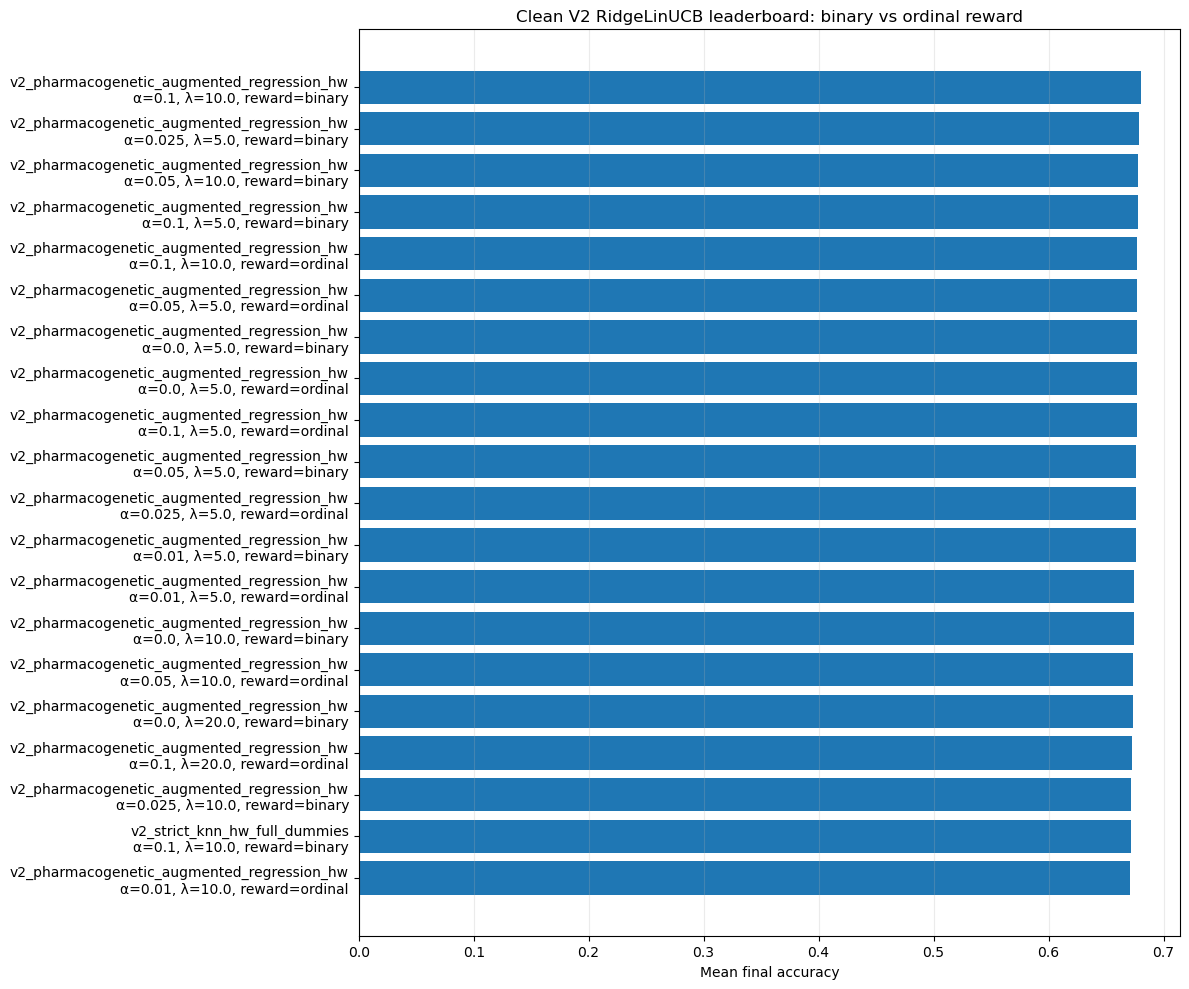

In [9]:
fig, ax = plot_feature_set_accuracy(
    ridge_summary,
    top_n=20,
    title='Clean V2 RidgeLinUCB leaderboard: binary vs ordinal reward',
)
fig.savefig(RESULTS_DIR / 'clean_v2_ridge_reward_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Reward comparison checkpoint

Use this table to compare whether ordinal reward improves exact bucket accuracy, low/high recall, or severe-error rates. The `final_reward_mean` column is reward-scheme-specific; `final_accuracy_mean` remains exact bucket accuracy for both reward schemes.

In [10]:
comparison_cols = [
    'reward_scheme', 'feature_set', 'algorithm', 'alpha', 'lambda_reg',
    'final_accuracy_mean', 'final_accuracy_ci95',
    'final_reward_mean', 'late_accuracy_mean', 'final_regret_mean',
]
ridge_summary[comparison_cols].sort_values('final_accuracy_mean', ascending=False).head(30)

,reward_scheme,feature_set,algorithm,alpha,lambda_reg,final_accuracy_mean,final_accuracy_ci95,final_reward_mean,late_accuracy_mean,final_regret_mean
0,binary,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.100,10.0,0.680282,0.003033,0.680282,0.6908,1767.4
1,binary,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.025, lambda=5.0)",0.025,5.0,0.678726,0.003774,0.678726,0.6936,1776.0
2,binary,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=10.0)",0.050,10.0,0.677605,0.004610,0.677605,0.6920,1782.2
3,binary,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=5.0)",0.100,5.0,0.677496,0.001781,0.677496,0.6928,1782.8
45,ordinal,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=10.0)",0.100,10.0,0.677279,0.003547,0.675398,0.6884,1794.4
46,ordinal,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=5.0)",0.050,5.0,0.677171,0.001515,0.675289,0.6920,1795.0
4,binary,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=5.0)",0.000,5.0,0.677135,0.002380,0.677135,0.6920,1784.8
47,ordinal,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.0, lambda=5.0)",0.000,5.0,0.676990,0.003720,0.675145,0.6916,1795.8
48,ordinal,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.1, lambda=5.0)",0.100,5.0,0.676845,0.001556,0.674059,0.6916,1801.8
5,binary,v2_pharmacogenetic_augmented_regression_hw,"RidgeLinUCB(alpha=0.05, lambda=5.0)",0.050,5.0,0.676302,0.003080,0.676302,0.6936,1789.4
